In [102]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score


In [103]:
# change path to dataset
train_df=pd.read_csv("/content/train (2).csv")
test_df=pd.read_csv("/content/test (2).csv")


In [104]:
train_df.head()

,Date,Open,High,Low,Close,Daily Returns,Daily Volatility,Adj Close,Volume,Dividends,Stock Splits,ticker,wihtin_30,monthly_volatility
0,2024-02-29,276.000000,276.000000,271.790009,272.609985,-0.009339,0.005518,266.255188,618700,0.0,0.0,WTW,1,0.017266
1,2021-07-23,326.839996,333.679993,326.839996,333.549988,0.021342,0.011218,311.551971,771800,0.0,0.0,EL,0,0.012829
2,2025-09-26,80.870003,81.879997,80.709999,81.620003,0.016692,0.011024,81.034721,2351600,0.0,0.0,MET,1,0.012075
3,2024-10-21,81.529999,82.180000,81.010002,81.379997,-0.002085,0.004982,79.746506,2364500,0.0,0.0,CARR,1,0.010432
4,2025-03-06,29.250000,30.020000,29.240000,29.969999,0.015244,0.021860,28.698242,10136400,0.0,0.0,HPQ,1,0.020389


In [105]:
test_df.head()

,Date,Open,High,Low,Close,Daily Returns,Daily Volatility,Adj Close,Volume,Dividends,Stock Splits,ticker,wihtin_30,monthly_volatility
0,2025-01-28,136.653458,138.524750,136.009903,136.029709,-0.000582,0.011872,134.733429,637916,0.0,0.0,J,1,0.010155
1,2022-07-20,176.100006,183.500000,175.610001,182.449997,0.049709,0.020139,180.259811,5654000,0.0,0.0,CRM,0,0.032663
2,2021-06-16,101.260002,101.260002,98.120003,99.940002,-0.019427,0.016751,92.928757,3913000,0.0,0.0,NUE,0,0.027835
3,2021-07-21,586.760010,586.760010,573.760010,583.719971,-0.005994,0.006914,580.500427,480800,0.0,0.0,REGN,0,0.013447
4,2020-09-29,83.070000,83.400002,82.040001,82.410004,-0.005551,0.006456,67.072006,2126100,0.0,0.0,DUK,0,0.012369


In [106]:
y = train_df["monthly_volatility"]

In [107]:
train_df.drop(columns="monthly_volatility", inplace=True)

In [108]:
x_train, x_test, y_train, y_test = train_test_split(train_df, y, test_size=0.3, random_state=42)

In [109]:
x_train.head()


,Date,Open,High,Low,Close,Daily Returns,Daily Volatility,Adj Close,Volume,Dividends,Stock Splits,ticker,wihtin_30
274587,2022-06-27,152.289993,153.080002,147.509995,148.050003,-0.026307,0.045399,148.050003,4140600,0.0,0.0,WDAY,0
130186,2023-04-13,74.970001,75.570000,74.269997,75.070000,-0.003452,0.010477,67.945595,1527900,0.0,0.0,PFG,0
402657,2024-10-14,103.760002,105.190002,102.959999,104.830002,0.012850,0.009994,103.571510,1110700,0.0,0.0,ZBH,1
237168,2021-09-27,257.779999,261.019989,257.429993,258.890015,0.012317,0.004965,239.364960,241200,0.0,0.0,EG,0
101767,2023-07-12,120.500000,121.830002,119.750000,121.709999,0.017642,0.017962,110.359459,3658600,0.0,0.0,EOG,0


In [110]:
y_train.head()

,monthly_volatility
274587,0.037616
130186,0.020912
402657,0.010484
237168,0.014879
101767,0.018945


In [111]:
x_train.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Daily Returns,float64
Daily Volatility,float64
Adj Close,float64
Volume,int64
Dividends,float64


In [112]:
x_train = x_train.select_dtypes(exclude = object)
x_test = x_test.select_dtypes(exclude = object)


In [113]:
x_train = x_train.sample(10000)
y_train = y_train.sample(10000)

In [114]:
rfc1=RandomForestRegressor(random_state=42, max_depth = 3)


In [115]:
rfc1.fit(x_train, y_train)


RandomForestRegressor(max_depth=3, random_state=42)

In [116]:
pred=rfc1.predict(x_test)


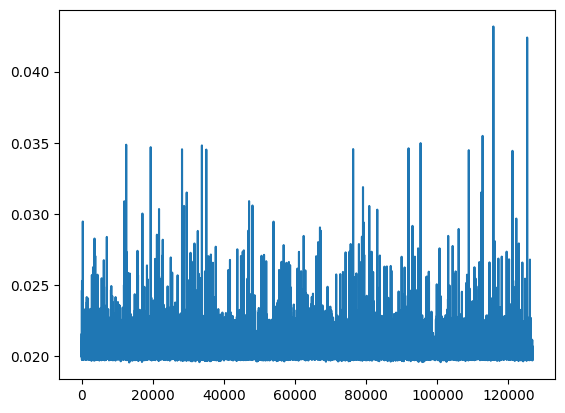

In [121]:
plt.plot(pred)
plt.show()

In [117]:
import numpy as np
from sklearn import metrics

print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, pred)))
mape = np.mean(np.abs((y_test - pred) / np.abs(y_test)))
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Accuracy:', round(100*(1 - mape), 2))

Mean Absolute Error (MAE): 0.008202801666994315
Mean Squared Error (MSE): 0.0001556821283143947
Root Mean Squared Error (RMSE): 0.012477264456378036
Mean Absolute Percentage Error (MAPE): 47.7
Accuracy: 52.3
